# Aspect-Based Sentiment Analysis with small and large language models

Evaluation of small and large language models on SemEval-2014 Task 4,
under zero-shot, few-shot and fine-tuning regimes.

The dataset is long-format (one row per aspect term). We reconstruct it to sentence level, hold out a
fixed test set used by every model, run inference through a uniform interface, store raw
outputs to disk, and compute metrics from those stored files.

## Configuration

In [1]:
import os, re, json, time, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ollama
from dotenv import load_dotenv
load_dotenv()

from google import genai
from google.genai import types

from sklearn.metrics import accuracy_score, f1_score, classification_report
from adjustText import adjust_text

SEED = 42

DATA_PATH  = Path("data/Restaurants_Train_v2.csv")
SPLIT_DIR  = Path("data")
PRED_DIR   = Path("predictions")
RESULTS_DIR = Path("results")
for d in (SPLIT_DIR, PRED_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

SENTIMENTS  = ["positive", "negative", "neutral", "conflict"]
TEST_SIZE   = 0.2

SLM_MODELS = ["gemma4:e2b", "qwen3.5:2b-q4_K_M"]

MODES = ["zeroshot", "fewshot"]

GEMINI_MODELS = ["gemini-3.5-flash"]

## Load and inspect

In [2]:
COL_ID = "id"
COL_TEXT = "Sentence"
COL_ASPECT = "Aspect Term"
COL_POLARITY = "polarity"

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

(3693, 6)
['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to']


,id,Sentence,Aspect Term,polarity,from,to
0,3121,But the staff was so horrible to us.,staff,negative,8,13
1,2777,"To be completely fair, the only redeeming fact...",food,positive,57,61
2,1634,"The food is uniformly exceptional, with a very...",food,positive,4,8
3,1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62
4,1634,"The food is uniformly exceptional, with a very...",menu,neutral,141,145


Reconstruct sentence-level examples: each example is a sentence plus the list of its
`(aspect, sentiment)` pairs. Sentences with no aspect term get an empty list. Rows belonging to the
same sentence are grouped by `id` or by the sentence text.

In [3]:
NULL_TOKENS = {"", "null", "nan", "none"}

def norm_aspect(a):
    return str(a).strip().lower()

group_key = COL_ID if df[COL_ID].nunique() < len(df) else COL_TEXT

def build_sentences(frame):
    rows = []
    for _, g in frame.groupby(group_key, sort=False):
        text = str(g[COL_TEXT].iloc[0])
        pairs = []
        for _, r in g.iterrows():
            a = str(r[COL_ASPECT])
            if norm_aspect(a) in NULL_TOKENS:
                continue
            pairs.append({"aspect": a.strip(), "sentiment": str(r[COL_POLARITY]).strip().lower()})
        rows.append({"id": str(g[COL_ID].iloc[0]), "text": text, "aspects": pairs})
    return rows

sentences = build_sentences(df)
print(f"{len(sentences)} sentences, {sum(len(s['aspects']) for s in sentences)} aspect terms")
sentences[0]

2021 sentences, 3693 aspect terms


{'id': '3121',
 'text': 'But the staff was so horrible to us.',
 'aspects': [{'aspect': 'staff', 'sentiment': 'negative'}]}

## Descriptive analysis

In [4]:
n_sent   = len(sentences)
n_aspect = sum(len(s["aspects"]) for s in sentences)
n_empty  = sum(1 for s in sentences if not s["aspects"])
counts   = [len(s["aspects"]) for s in sentences]

sent_dist = pd.Series(
    [p["sentiment"] for s in sentences for p in s["aspects"]]
).value_counts()

print(f"sentences:                 {n_sent}")
print(f"aspect terms:              {n_aspect}")
print(f"sentences without aspect:  {n_empty} ({n_empty/n_sent:.1%})")
print(f"aspects per sentence:      mean {np.mean(counts):.2f}, max {max(counts)}")
print(f"mean sentence length (ch): {np.mean([len(s['text']) for s in sentences]):.0f}")
print("\nsentiment distribution:")
print(sent_dist)

sentences:                 2021
aspect terms:              3693
sentences without aspect:  0 (0.0%)
aspects per sentence:      mean 1.83, max 9
mean sentence length (ch): 82

sentiment distribution:
positive    2164
negative     805
neutral      633
conflict      91
Name: count, dtype: int64


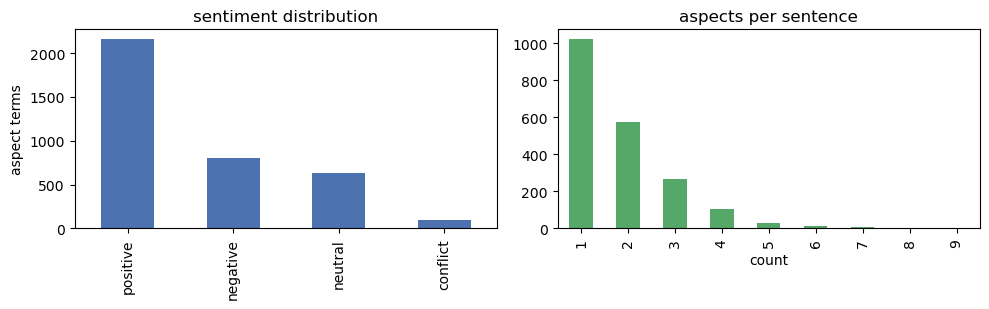

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
sent_dist.reindex(SENTIMENTS).plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("sentiment distribution"); ax[0].set_ylabel("aspect terms")
pd.Series(counts).value_counts().sort_index().plot.bar(ax=ax[1], color="#55A868")
ax[1].set_title("aspects per sentence"); ax[1].set_xlabel("count")
plt.tight_layout(); plt.show()

`neutral` and `conflict` are expected to be rare, which is why sentiment is later reported with
macro-F1 and not only accuracy.

## Train / test split

Random split at the sentence level with a fixed seed. The split is saved so that every model in this
project (including the fine-tuned models trained later) uses the exact same test set.

In [6]:
train, test = train_test_split(sentences, test_size=TEST_SIZE, random_state=SEED, shuffle=True)
print(f"train {len(train)}  test {len(test)}")

def save_json(rows, path):
    Path(path).write_text(json.dumps(rows, ensure_ascii=False, indent=2), encoding="utf-8")

def save_flat_csv(rows, path):
    flat = [{"id": s["id"], "text": s["text"], "aspect": p["aspect"], "sentiment": p["sentiment"]}
            for s in rows for p in s["aspects"]]
    pd.DataFrame(flat).to_csv(path, index=False)

save_json(train, SPLIT_DIR / "train.json"); save_flat_csv(train, SPLIT_DIR / "train.csv")
save_json(test,  SPLIT_DIR / "test.json");  save_flat_csv(test,  SPLIT_DIR / "test.csv")

train 1616  test 405


## Prompt and output parsing

The prompt forces a JSON-only answer. `build_prompt` already takes an `examples` argument so the
few-shot regime is just a different call, not a different code path.

Generative models return free text, so parsing is in two steps: direct JSON parse, then a repair attempt
(strip reasoning traces and code fences, extract the array). If both fail the output is recorded as a
format failure.

In [7]:
SYSTEM_INSTRUCTION = (
    "You are an aspect-based sentiment analysis system for customer reviews.\n"
    "Given one sentence, extract every aspect term that is explicitly mentioned and its sentiment.\n"
    "An aspect term is a word or phrase copied verbatim from the sentence that names something being evaluated.\n"
    "sentiment is exactly one of: positive, negative, neutral, conflict "
    "(conflict = both positive and negative).\n"
    "If the sentence contains no aspect term, return an empty array.\n"
    "Return ONLY a JSON array and nothing else. "
    'Each element must be {"aspect": "<term>", "sentiment": "<sentiment>"}.'
)

def build_prompt(text, examples=None):
    parts = [SYSTEM_INSTRUCTION, ""]
    if examples:
        for ex in examples:
            parts.append(f'Sentence: "{ex["text"]}"')
            parts.append("Output: " + json.dumps(
                [{"aspect": p["aspect"], "sentiment": p["sentiment"]} for p in ex["aspects"]],
                ensure_ascii=False))
            parts.append("")
    parts.append(f'Sentence: "{text}"')
    parts.append("Output:")
    return "\n".join(parts)

In [8]:
def _strip_think(text):
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE)

def _extract_array(text):
    s, e = text.find("["), text.rfind("]")
    return text[s:e + 1] if (s != -1 and e > s) else None

def _normalize_pairs(data):
    if isinstance(data, dict):
        for k in ("aspects", "results", "data", "items"):
            if isinstance(data.get(k), list):
                data = data[k]; break
        else:
            data = [data] if ("aspect" in data or "term" in data) else None
    if not isinstance(data, list):
        return None
    out = []
    for item in data:
        if not isinstance(item, dict):
            continue
        a = item.get("aspect", item.get("term"))
        s = item.get("sentiment", item.get("polarity"))
        if a is None or s is None:
            continue
        out.append({"aspect": str(a).strip(), "sentiment": str(s).strip().lower()})
    return out

def parse_prediction(raw):
    # returns (pairs, ok); ok=False -> output was not parseable as the expected JSON
    text = re.sub(r"```(?:json)?", "", _strip_think(str(raw))).strip()
    for cand in (text, _extract_array(text)):
        if not cand:
            continue
        try:
            data = json.loads(cand)
        except Exception:
            continue
        pairs = _normalize_pairs(data)
        if pairs is not None:
            return pairs, True
    return [], False

## Local model client

A thin wrapper with a single `predict(prompt) -> (raw_text, seconds)` method. The API models added
later expose the same method, so the inference loop never needs to know which kind of model it is
talking to. Temperature is 0 for determinism. Thinking is disabled so the models answer with JSON
directly instead of a reasoning trace.

In [9]:
class OllamaModel:
    def __init__(self, name, think=False, num_predict=512):
        self.name = name
        self.think = think
        self.options = {"temperature": 0, "num_predict": num_predict}

    def predict(self, prompt):
        msgs = [{"role": "user", "content": prompt}]
        t0 = time.perf_counter()
        try:
            resp = ollama.chat(model=self.name, messages=msgs, options=self.options, think=self.think)
        except TypeError:
            # older ollama client without the 'think' argument
            resp = ollama.chat(model=self.name, messages=msgs, options=self.options)
        dt = time.perf_counter() - t0
        return resp["message"]["content"], dt

def unload(model_name):
    # free the model from memory so the next model's measurements are clean
    try:
        ollama.generate(model=model_name, prompt="", keep_alive=0)
    except Exception:
        pass

def loaded_size_mb(model_name):
    # size ollama reports for the currently loaded model (RAM, no GPU)
    try:
        for m in ollama.ps().get("models", []):
            if model_name in (m.get("model"), m.get("name")):
                return round(m.get("size", 0) / 1e6, 1)
    except Exception:
        pass
    return None

## API model client

Same `predict(prompt) -> (raw, seconds)` contract as `OllamaModel`, so the inference loop is unchanged. Thinking is set to the lowest available level (Gemini 3.5 Flash cannot fully disable it) and any leaked reasoning is stripped by the existing parser. No structured-output schema is used - the model gets the same JSON instruction as the local models, so format compliance stays a comparable metric across all systems. A short retry with backoff covers transient API/network errors. Memory is not measurable for a hosted model, so `mem_mb` is left null and only latency is recorded (it includes network time).

In [10]:
_gemini_client = None
def _get_gemini_client():
    global _gemini_client
    if _gemini_client is None:
        _gemini_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
    return _gemini_client

class GeminiModel:
    def __init__(self, name, num_predict=512, max_retries=3):
        self.name = name
        self.max_retries = max_retries
        self.config = types.GenerateContentConfig(
            temperature=0,
            max_output_tokens=num_predict,
            thinking_config=types.ThinkingConfig(thinking_level="MINIMAL"),
        )

    def predict(self, prompt):
        client = _get_gemini_client()
        t0 = time.perf_counter()
        last = None
        for attempt in range(self.max_retries):
            try:
                resp = client.models.generate_content(
                    model=self.name, contents=prompt, config=self.config)
                return (resp.text or ""), time.perf_counter() - t0
            except Exception as e:
                last = e
                time.sleep(2 ** attempt)
        # all retries failed: empty output -> recorded as a format failure
        print(f"gemini call failed after {self.max_retries} tries: {last}")
        return "", time.perf_counter() - t0

def make_client(model_name):
    if model_name in GEMINI_MODELS:
        return GeminiModel(model_name)
    else:
        return OllamaModel(model_name)

## Inference

Outer loop over models, inner loop over regimes: a model is loaded once and reused for all its
regimes, and only one model is loaded at a time, which keeps the memory and time measurements
attributable to a single model.

Predictions are written to JSONL one line at a time, so an interrupted run resumes from the last
completed `id` instead of starting over. Each record carries the gold pairs, making evaluation
self-contained from the file.

In [11]:
def pred_path(model, mode):
    safe = model.replace(":", "_").replace("/", "_")
    return PRED_DIR / f"{safe}__{mode}.jsonl"

def load_done(path):
    if not path.exists():
        return set()
    ids = set()
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            ids.add(json.loads(line)["id"])
    return ids

def few_shot_examples(k_per_class=1):
    chosen, seen = [], {s: 0 for s in SENTIMENTS}
    for ex in train:
        labels = {p["sentiment"] for p in ex["aspects"]}
        if ex["aspects"] and any(seen[l] < k_per_class for l in labels if l in seen):
            chosen.append(ex)
            for l in labels:
                if l in seen:
                    seen[l] += 1
        if all(v >= k_per_class for v in seen.values()):
            break
    return chosen

def run(model_name, mode, data):
    model = make_client(model_name)
    examples = few_shot_examples() if mode == "fewshot" else None
    path = pred_path(model_name, mode)
    done = load_done(path)
    todo = [s for s in data if s["id"] not in done]
    print(f"{model_name} / {mode}: {len(todo)} to do ({len(done)} cached)")

    mem = None
    with path.open("a", encoding="utf-8") as f:
        for i, s in enumerate(todo, 1):
            raw, dt = model.predict(build_prompt(s["text"], examples))
            pairs, ok = parse_prediction(raw)
            if mem is None:
                mem = loaded_size_mb(model_name)
            rec = {"id": s["id"], "text": s["text"], "gold": s["aspects"],
                   "pred": pairs, "ok": ok, "time": dt, "mem_mb": mem}
            f.write(json.dumps(rec, ensure_ascii=False) + "\n"); f.flush()
            if i % 25 == 0:
                print(f"{i}/{len(todo)}")
    return path

In [12]:
ex = few_shot_examples()
print(f"{len(ex)} examples choosen\n")
for e in ex:
    print(e["text"])
    for p in e["aspects"]:
        print(f"   {p['aspect']} -> {p['sentiment']}")
    print()

4 examples choosen

When you want a piece of beef, head on over.
   beef -> positive

night without a reservation, we had to wait at the bar for a little while, but the manager was so nice and made our wait a great experience.
   manager -> positive
   reservation -> neutral
   bar -> neutral
   wait -> positive

While we enjoyed the food, we were highly disappointed by the poor service (waiter was not quite competent and SLOW service) and lack of remorse.
   food -> positive
   service -> negative
   waiter -> negative
   service -> negative

The Italian food has flavor (that can be sort of surprising on the UES), and the service turns from a nightmare to attentive,they sort of remind me of the NY Yankees of the late 90's, no matter how bad it look, you knew that there was a rally just around the corner...
   Italian food -> positive
   service -> conflict



In [13]:
for model_name in SLM_MODELS:
    for mode in MODES:
        run(model_name, mode, test)
    unload(model_name)

gemma4:e2b / zeroshot: 0 to do (405 cached)
gemma4:e2b / fewshot: 0 to do (405 cached)
qwen3.5:2b-q4_K_M / zeroshot: 0 to do (405 cached)
qwen3.5:2b-q4_K_M / fewshot: 0 to do (405 cached)


In [14]:
for model_name in GEMINI_MODELS:
    for mode in MODES:
        run(model_name, mode, test)

gemini-3.5-flash / zeroshot: 0 to do (405 cached)
gemini-3.5-flash / fewshot: 0 to do (405 cached)


## Evaluation

Metrics are computed from the stored predictions, so this section can be re-run and edited without touching the models.

- **ATE** - precision / recall / F1 over the set of extracted aspect terms (exact match). Incorrect aspects lower precision, missed ones lower recall.
- **ASC** - sentiment accuracy and macro-F1, computed on the aspects the model extracted correctly.
- **End-to-end** - F1 over `(aspect, sentiment)` pairs, a pair counting as correct only if both are right. This is the main number for comparing models.
- **Compliance** - share of outputs that parsed. Quality metrics are computed on parsed outputs only, so they must always be read together with compliance.

In [15]:
def _aset(pairs):  return {norm_aspect(p["aspect"]) for p in pairs}
def _pset(pairs):  return {(norm_aspect(p["aspect"]), p["sentiment"]) for p in pairs}

def _prf(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return p, r, (2 * p * r / (p + r) if p + r else 0.0)

def _micro(records, keyfn):
    tp = fp = fn = 0
    for r in records:
        g, p = keyfn(r["gold"]), keyfn(r["pred"])
        tp += len(g & p); fp += len(p - g); fn += len(g - p)
    return _prf(tp, fp, fn)

def evaluate_file(path):
    records = [json.loads(l) for l in Path(path).read_text(encoding="utf-8").splitlines() if l.strip()]
    ok = [r for r in records if r["ok"]]
    ate_p, ate_r, ate_f = _micro(ok, _aset)
    e2e_p, e2e_r, e2e_f = _micro(ok, _pset)

    y_t, y_p = [], []
    for r in ok:
        gmap = {norm_aspect(x["aspect"]): x["sentiment"] for x in r["gold"]}
        pmap = {norm_aspect(x["aspect"]): x["sentiment"] for x in r["pred"]}
        for a in set(gmap) & set(pmap):
            y_t.append(gmap[a]); y_p.append(pmap[a])

    asc_acc = accuracy_score(y_t, y_p) if y_t else 0.0
    asc_f1  = f1_score(y_t, y_p, labels=SENTIMENTS, average="macro", zero_division=0) if y_t else 0.0

    asc_per_class = {}
    if y_t:
        report = classification_report(y_t, y_p, labels=SENTIMENTS, output_dict=True, zero_division=0)
        for cls in SENTIMENTS:
            asc_per_class[f"asc_f1_{cls}"] = report[cls]["f1-score"]
    else:
        for cls in SENTIMENTS:
            asc_per_class[f"asc_f1_{cls}"] = 0.0

    times = [r["time"] for r in records]
    return {
        "n": len(records), "compliance": len(ok) / len(records) if records else 0.0,
        "ate_p": ate_p, "ate_r": ate_r, "ate_f1": ate_f,
        "asc_acc": asc_acc, "asc_macro_f1": asc_f1,
        **asc_per_class,
        "e2e_p": e2e_p, "e2e_r": e2e_r, "e2e_f1": e2e_f,
        "avg_time_s": float(np.mean(times)) if times else 0.0,
        "med_time_s": float(np.median(times)) if times else 0.0,
        "mem_mb": records[0].get("mem_mb") if records else None,
    }

def parse_name(path):
    stem = Path(path).stem
    model, mode = stem.split("__")
    return model.replace("_", ":", 1), mode

rows = []
for path in sorted(glob.glob(str(PRED_DIR / "*.jsonl"))):
    model, mode = parse_name(path)
    rows.append({"model": model, "mode": mode, **evaluate_file(path)})

results = pd.DataFrame(rows)
results.to_csv(RESULTS_DIR / "results.csv", index=False)
results.round(3)

,model,mode,n,compliance,ate_p,ate_r,ate_f1,asc_acc,asc_macro_f1,asc_f1_positive,asc_f1_negative,asc_f1_neutral,asc_f1_conflict,e2e_p,e2e_r,e2e_f1,avg_time_s,med_time_s,mem_mb
0,gemini-3.5-flash,fewshot,405,1.000,0.805,0.862,0.832,0.873,0.733,0.941,0.847,0.716,0.429,0.706,0.752,0.728,2.908,0.903,NaN
1,gemini-3.5-flash,zeroshot,405,0.995,0.804,0.759,0.781,0.885,0.725,0.948,0.869,0.640,0.444,0.716,0.671,0.693,9.229,1.107,NaN
2,gemma4:e2b,fewshot,405,1.000,0.819,0.642,0.720,0.863,0.677,0.932,0.842,0.518,0.417,0.711,0.554,0.623,1.601,1.354,7678.2
3,gemma4:e2b,zeroshot,405,1.000,0.704,0.620,0.659,0.832,0.662,0.918,0.773,0.633,0.323,0.590,0.516,0.551,2.318,2.069,7678.2
4,gemma4:e2b_finetuned,finetuned,405,0.993,0.803,0.768,0.785,0.826,0.663,0.910,0.808,0.557,0.378,0.665,0.633,0.649,6.850,5.022,NaN
5,qwen3.5:2b-q4_K_M,fewshot,405,1.000,0.729,0.613,0.666,0.663,0.485,0.775,0.701,0.348,0.118,0.488,0.408,0.444,3.690,3.554,1630.2
6,qwen3.5:2b-q4_K_M,zeroshot,405,0.879,0.614,0.545,0.577,0.760,0.528,0.844,0.784,0.350,0.133,0.468,0.415,0.440,1.867,1.770,1630.2
7,qwen3:5_2b_finetuned,finetuned,405,1.000,0.861,0.857,0.859,0.849,0.689,0.933,0.797,0.682,0.345,0.734,0.728,0.731,4.351,4.024,NaN


## Results

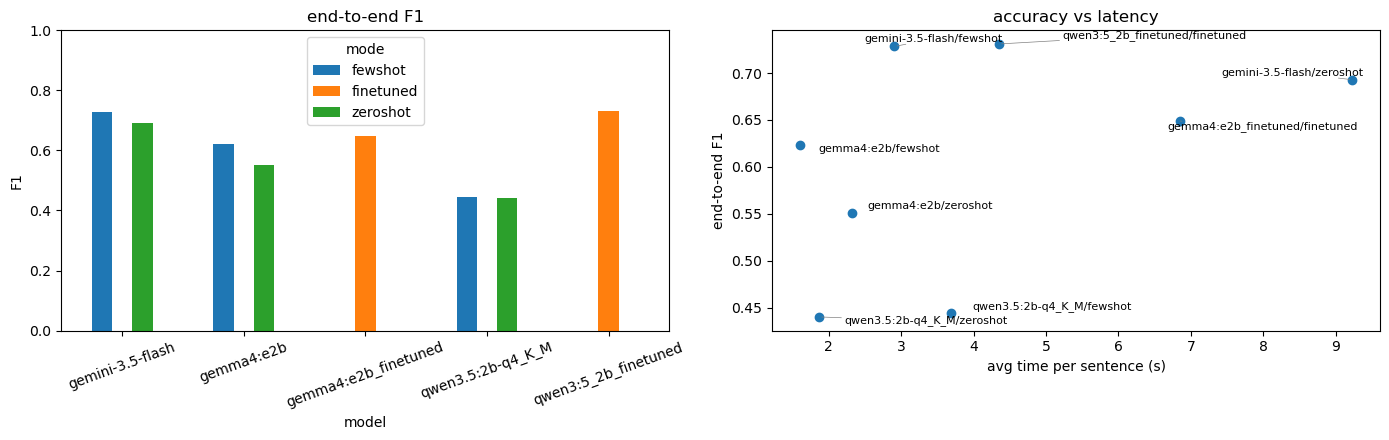

In [16]:
if not results.empty:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    
    pivot = results.pivot_table(index="model", columns="mode", values="e2e_f1")
    pivot.plot.bar(ax=ax[0])
    ax[0].set_title("end-to-end F1"); ax[0].set_ylabel("F1")
    ax[0].set_ylim(0, 1); ax[0].tick_params(axis="x", rotation=20)
    
    ax[1].scatter(results["avg_time_s"], results["e2e_f1"])
    
    texts = []
    for _, r in results.iterrows():
        t = ax[1].text(r["avg_time_s"], r["e2e_f1"],
                       f'{r["model"]}/{r["mode"]}', fontsize=8)
        texts.append(t)
    
    adjust_text(texts, ax=ax[1],
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
    
    ax[1].set_xlabel("avg time per sentence (s)")
    ax[1].set_ylabel("end-to-end F1")
    ax[1].set_title("accuracy vs latency")
    plt.tight_layout(); plt.show()